# Predictive Model Benchmarking: Classification & Regression

### Question 1 – Classification (Business): Bank Marketing

### Task 1
#### Problem Overview
The goal of this task is to build a classification model that predicts whether a bank customer will subscribe to a term deposit.  
The dataset used is the **UCI Bank Marketing dataset**, which contains information about customer demographics, marketing campaign 
interactions, and economic indicators.
#### Target Variable
The target variable is **y**, which indicates whether the customer subscribed to a term deposit.
- yes → customer subscribed
- no → customer did not subscribe
#### Objective: 
Build machine learning models that predict this outcome and evaluate their performance using metrics such as:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## 1. Load and Inspect the Dataset

In [1]:
# Install required packages
!pip install ucimlrepo
!pip install xgboost

In [2]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset from UCI
from ucimlrepo import fetch_ucirepo

# Model utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

In [3]:
# Load Bank Marketing dataset
bank_data = fetch_ucirepo(id=222)

# Features
X = bank_data.data.features.copy()

# Target
y = bank_data.data.targets.copy()

In [4]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst rows of X")
print(X.head())

print("\nFirst rows of y")
print(y.head())

print("\nColumns in y:")
print(y.columns)

Shape of X: (45211, 16)
Shape of y: (45211, 1)

First rows of X
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome  
0     NaN            5   may       261         1     -1         0      NaN  
1     NaN            5   may       151         1     -1         0      NaN  
2     NaN            5   may        76         1     -1         0      NaN  
3     NaN            5   may        92         1     -1         0      NaN  
4     NaN            5   may       198         1     -1         0      NaN  

First rows of y
    y
0  no


#### 2. Target Variable Processing and Target Class Distribution

In [5]:
# Convert one-column dataframe to series
y = y.squeeze()

# Clean text
y = y.astype(str).str.strip().str.lower()

# Convert yes/no to binary
y = y.replace({'yes':1, 'no':0})

print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


/var/folders/67/v_4xltcs4dlbfdhbdt9nlmv00000gn/T/ipykernel_10549/1290699451.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'yes':1, 'no':0})


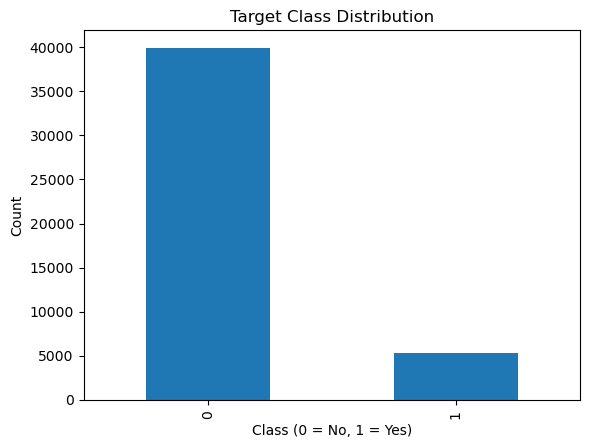

In [6]:
# Plot target class distribution
y.value_counts().sort_index().plot(kind='bar')
plt.title("Target Class Distribution")
plt.xlabel("Class (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [7]:
# Check missing values in features
missing_values = X.isna().sum().sort_values(ascending=False)

print("Top columns with missing values:")
print(missing_values.head(20))

Top columns with missing values:
poutcome       36959
contact        13020
education       1857
job              288
age                0
marital            0
default            0
balance            0
housing            0
loan               0
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
dtype: int64


#### 3. Identify Numeric and Categorical Features

In [8]:
# Numeric columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

Numeric columns:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


#### 4. Train–Test Split

In [9]:
# 80/20 split with stratification on y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True))

X_train shape: (36168, 16)
X_test shape: (9043, 16)

Train target proportions:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64

Test target proportions:
y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


#### 5. Feature Preprocessing

In [10]:
# Preprocess features:
# - standardize numeric columns
# - one-hot encode categorical columns
# - ignore unknown categories safely
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

#### 6. Cross Validation Setup

In [11]:
# 5-fold stratified CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### 7. Model Training and Hyperparameter Tuning

In [12]:
# Pipeline for Logistic Regression
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

# Parameter grid
param_lr = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear']
}

# Grid search
grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_lr,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression params:")
print(grid_lr.best_params_)

print("\nBest Logistic Regression CV ROC-AUC:")
print(grid_lr.best_score_)

Best Logistic Regression params:
{'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Best Logistic Regression CV ROC-AUC:
0.9074350527398742


In [13]:
# Pipeline for KNN
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('model', KNeighborsClassifier())
])

# Parameter grid
param_knn = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

# Grid search
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_knn,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_knn.fit(X_train, y_train)

print("Best KNN params:")
print(grid_knn.best_params_)

print("\nBest KNN CV ROC-AUC:")
print(grid_knn.best_score_)

Best KNN params:
{'model__n_neighbors': 9, 'model__weights': 'distance'}

Best KNN CV ROC-AUC:
0.868150362663421


In [14]:
# Pipeline for Decision Tree
pipe_dt = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Parameter grid
param_dt = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_leaf': [1, 5, 10, 20]
}

# Grid search
grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_dt,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_dt.fit(X_train, y_train)

print("Best Decision Tree params:")
print(grid_dt.best_params_)

print("\nBest Decision Tree CV ROC-AUC:")
print(grid_dt.best_score_)

Best Decision Tree params:
{'model__max_depth': None, 'model__min_samples_leaf': 20}

Best Decision Tree CV ROC-AUC:
0.8879633718823214


In [15]:
# Pipeline for Random Forest
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Parameter grid
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

# Grid search
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_rf,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_rf.fit(X_train, y_train)

print("Best Random Forest params:")
print(grid_rf.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(grid_rf.best_score_)

Best Random Forest params:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Best Random Forest CV ROC-AUC:
0.9310724602560935


In [16]:
# Pipeline for KNN
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('model', KNeighborsClassifier())
])

# Parameter grid
param_knn = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

# Grid search
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_knn,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_knn.fit(X_train, y_train)

print("Best KNN params:")
print(grid_knn.best_params_)

print("\nBest KNN CV ROC-AUC:")
print(grid_knn.best_score_)

Best KNN params:
{'model__n_neighbors': 9, 'model__weights': 'distance'}

Best KNN CV ROC-AUC:
0.868150362663421


In [17]:
# Pipeline for Gradient Boosting
pipe_gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier())
])

# Parameter grid
param_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3]
}

# Grid search
grid_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_gb,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_gb.fit(X_train, y_train)

print("Best Gradient Boosting params:")
print(grid_gb.best_params_)

print("\nBest Gradient Boosting CV ROC-AUC:")
print(grid_gb.best_score_)

Best Gradient Boosting params:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

Best Gradient Boosting CV ROC-AUC:
0.9313049112899806


In [18]:
# Pipeline for XGBoost
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])

# Parameter grid
param_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

# Grid search
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_xgb,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

# Fit on training data only
grid_xgb.fit(X_train, y_train)

print("Best XGBoost params:")
print(grid_xgb.best_params_)

print("\nBest XGBoost CV ROC-AUC:")
print(grid_xgb.best_score_)

Best XGBoost params:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Best XGBoost CV ROC-AUC:
0.9353844104700115


#### 8. Model Comparison

In [19]:
# Compare best CV ROC-AUC values
cv_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Best CV ROC-AUC': [
        grid_lr.best_score_,
        grid_dt.best_score_,
        grid_rf.best_score_,
        grid_knn.best_score_,
        grid_gb.best_score_,
        grid_xgb.best_score_
    ]
})

cv_results = cv_results.sort_values(by='Best CV ROC-AUC', ascending=False)

print("Cross-validation comparison:")
print(cv_results)

Cross-validation comparison:
                 Model  Best CV ROC-AUC
5              XGBoost         0.935384
4    Gradient Boosting         0.931305
2        Random Forest         0.931072
0  Logistic Regression         0.907435
1        Decision Tree         0.887963
3                  KNN         0.868150


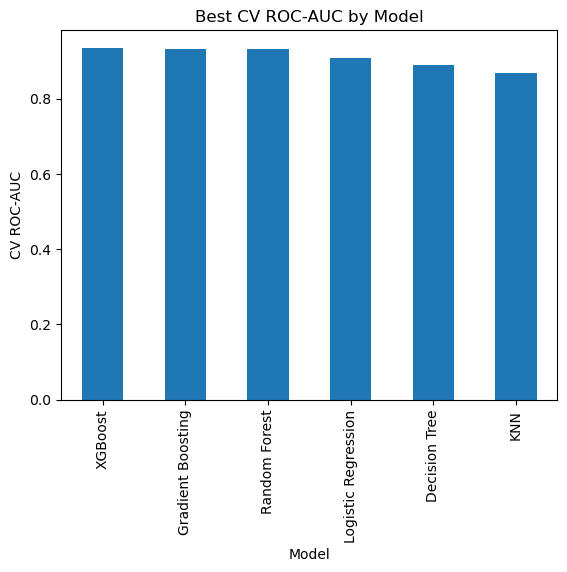

In [20]:
# Plot cross-validation ROC-AUC comparison
cv_results.set_index('Model')['Best CV ROC-AUC'].plot(kind='bar')
plt.title("Best CV ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("CV ROC-AUC")
plt.show()

In [21]:
# Function to calculate final test metrics
def evaluate_model(model, X_test, y_test):
    # Predicted class labels
    y_pred = model.predict(X_test)

    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

In [22]:
# Evaluate all tuned models on the test set
results = pd.DataFrame({
    'Logistic Regression': evaluate_model(grid_lr.best_estimator_, X_test, y_test),
    'Decision Tree': evaluate_model(grid_dt.best_estimator_, X_test, y_test),
    'Random Forest': evaluate_model(grid_rf.best_estimator_, X_test, y_test),
    'KNN': evaluate_model(grid_knn.best_estimator_, X_test, y_test),
    'Gradient Boosting': evaluate_model(grid_gb.best_estimator_, X_test, y_test),
    'XGBoost': evaluate_model(grid_xgb.best_estimator_, X_test, y_test)
}).T

results = results.sort_values(by='ROC-AUC', ascending=False)

print("Final test set results:")
print(results)

Final test set results:
                     Accuracy  Precision    Recall        F1   ROC-AUC
XGBoost              0.909986   0.657623  0.481096  0.555677  0.933875
Random Forest        0.906005   0.689781  0.357278  0.470735  0.930773
Gradient Boosting    0.909212   0.669528  0.442344  0.532726  0.929639
Logistic Regression  0.900807   0.644524  0.339319  0.444582  0.906387
Decision Tree        0.898374   0.584447  0.454631  0.511430  0.884349
KNN                  0.903019   0.662478  0.348771  0.456966  0.864616


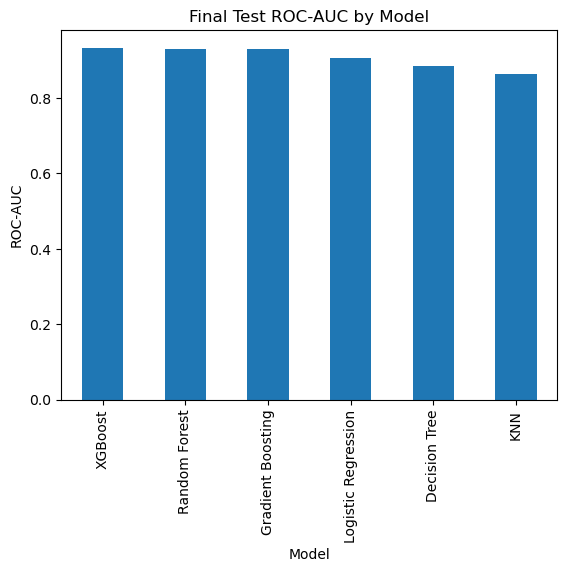

In [23]:
# Plot final test ROC-AUC comparison
results['ROC-AUC'].sort_values(ascending=False).plot(kind='bar')
plt.title("Final Test ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.show()

In [24]:
# Select winner based on test ROC-AUC
best_name = results.index[0]

# Store all tuned best estimators
best_model_dict = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'Gradient Boosting': grid_gb.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_
}

# Final best model
best_model = best_model_dict[best_name]

print("Winning model:", best_name)

Winning model: XGBoost


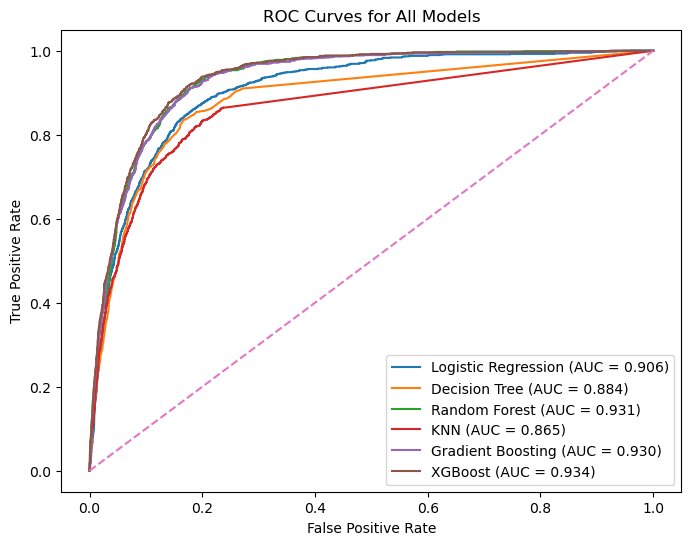

In [25]:
#ROC curve for all contender models
plt.figure(figsize=(8, 6))

for name, model in best_model_dict.items():
    # Get predicted probability of class 1
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve coordinates
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Compute AUC
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Reference line for random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()

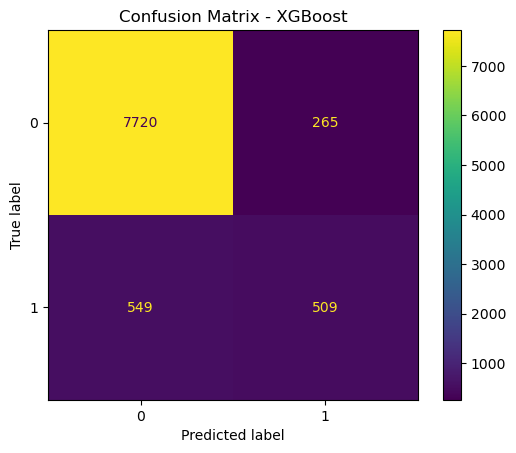

In [26]:
#Confusion matrix for the winning model
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

#### Conclusion
For the Bank Marketing dataset, several classification models were trained and tuned using GridSearchCV with Stratified 5-Fold Cross-Validation on the training set. The models evaluated included Logistic Regression, Decision Tree, Random Forest, KNN, Gradient Boosting, and XGBoost.

Model selection was primarily based on ROC-AUC during cross-validation. After tuning hyperparameters and evaluating the models on the test set using Accuracy, Precision, Recall, F1, and ROC-AUC, the **XGBoost classifier** achieved the best overall performance.

Best Hyperparameters:
- n_estimators = 200
- max_depth = 5
- learning_rate = 0.1

XGBoost likely generalizes best because boosting sequentially corrects the errors of previous trees and can capture nonlinear relationships between features while controlling overfitting through regularization. The ROC curve comparison and confusion matrix also indicate strong predictive performance on unseen data.

### Question 2 – Regression: Real Estate Valuation — Price per Unit Area

### Task 2
#### Problem Overview
The goal of this task is to build regression models to predict the price per unit area of houses using the UCI Real Estate Valuation dataset.
The dataset contains information about housing characteristics such as transaction date, house age, distance to the nearest MRT station, number of nearby convenience stores, and geographic coordinates in New Taipei City, Taiwan.
#### Target Variable
The target variable is Y house price of unit area, which represents the continuous price value per unit area of a property.
#### Objective
Build multiple regression models that can accurately predict the housing price per unit area and compare their performance.

#### 1. Load and Inspect the Dataset

In [27]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset from UCI
from ucimlrepo import fetch_ucirepo

# Train-test split and cross-validation
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# Preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regression models
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [28]:
# Load the Real Estate Valuation dataset from UCI
# id=477 is the Real Estate Valuation dataset
real_estate = fetch_ucirepo(id=477)

# X = all feature columns
X = real_estate.data.features.copy()

# y = target column
y = real_estate.data.targets.copy()

# Check dataset shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Preview data
print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 rows of y:")
display(y.head())

Shape of X: (414, 6)
Shape of y: (414, 1)

First 5 rows of X:


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245



First 5 rows of y:


,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1


In [29]:
# Dataset shape
print("X shape:", X.shape)
print("y shape:", y.shape)

# Column names
print(X.columns)

# Data types
X.info()

# Missing values
print(X.isnull().sum())

# Basic statistics
X.describe()

X shape: (414, 6)
y shape: (414, 1)
Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB
X1 transaction date                       0
X2 house age          

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270


The dataset contains features describing property characteristics such as house age, distance to MRT station, number of nearby convenience stores, and geographical coordinates. The target variable is the house price per unit area.

#### 2. Define Target Variable

In [30]:
# Convert target from one-column dataframe to series
y = y.squeeze()

# Check target type and first values
print("Target type:", type(y))
print("\nFirst 5 values of y:")
print(y.head())

Target type: <class 'pandas.core.series.Series'>

First 5 values of y:
0    37.9
1    42.2
2    47.3
3    54.8
4    43.1
Name: Y house price of unit area, dtype: float64


#### 3. Exploratory Data Analysis

In [31]:
# Summary statistics for features
print("Summary statistics for X:")
display(X.describe())

# Summary statistics for target
print("Summary statistics for y:")
display(y.describe())

Summary statistics for X:


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270


Summary statistics for y:


count    414.000000
mean      37.980193
std       13.606488
min        7.600000
25%       27.700000
50%       38.450000
75%       46.600000
max      117.500000
Name: Y house price of unit area, dtype: float64

In [32]:
# Check missing values
print("Missing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

Missing values in X:
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
dtype: int64

Missing values in y:
0


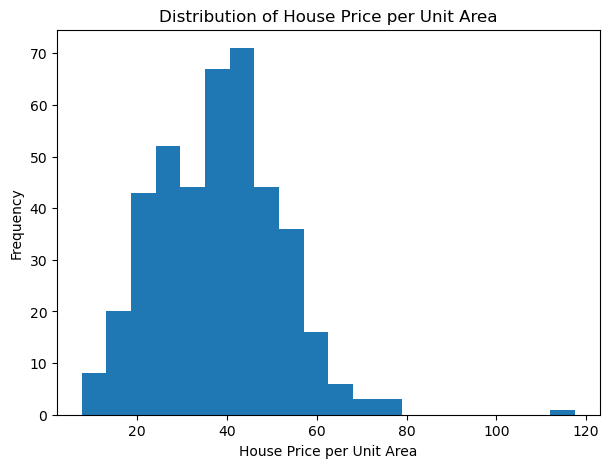

In [33]:
# Plot target distribution
plt.figure(figsize=(7, 5))
plt.hist(y, bins=20)
plt.title("Distribution of House Price per Unit Area")
plt.xlabel("House Price per Unit Area")
plt.ylabel("Frequency")
plt.show()

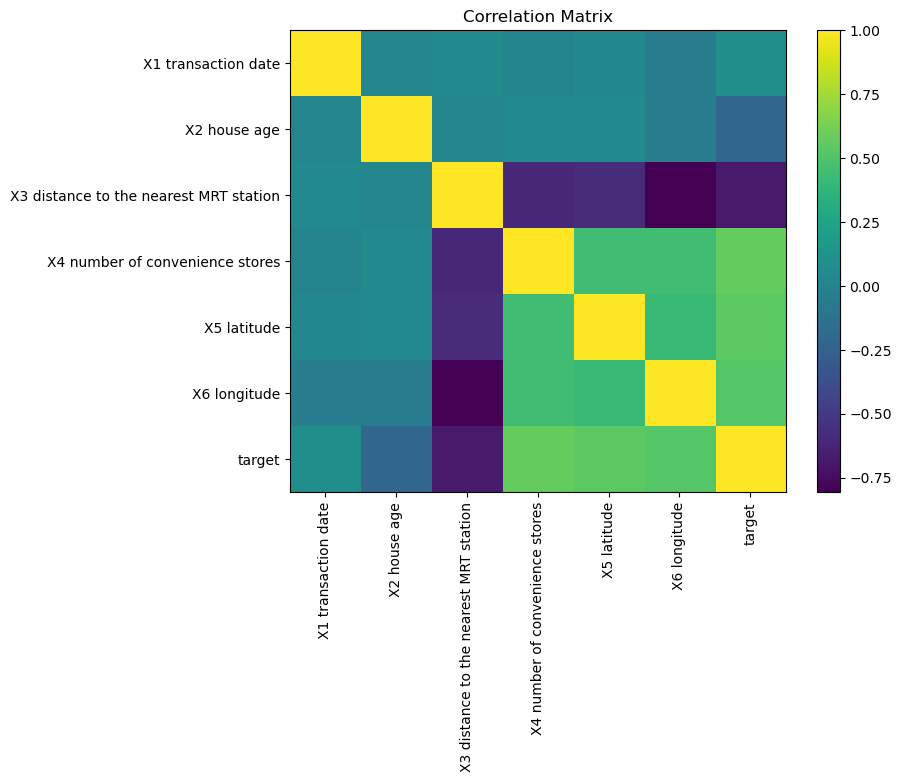

In [34]:
# Correlation matrix for numeric variables
plt.figure(figsize=(8, 6))
corr_matrix = pd.concat([X, y.rename("target")], axis=1).corr(numeric_only=True)
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

#### 4. Train-Test Split

In [35]:
# Split dataset into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (331, 6)
X_test shape: (83, 6)
y_train shape: (331,)
y_test shape: (83,)


The dataset is split into 80% training data and 20% testing data to evaluate model generalization.

#### 5. Feature Preprocessing

In [36]:
# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
Categorical columns: []


In [37]:
# Preprocessing:
# - Standardize numeric columns
# - One-hot encode categorical columns if present
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

#### 6. Cross-Validation Setup

In [38]:
# Create 5-fold cross-validation object
# This matches the assignment requirement: KFold(k=5)
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

KFold(n_splits=5, random_state=42, shuffle=True)


#### 7. Model Training and Hyperparameter Tuning

#### Ridge Regression

In [39]:
# Build pipeline for Ridge Regression
pipe_ridge = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge())
])

# Hyperparameter grid
param_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

# Grid search using RMSE as primary selection metric
# sklearn uses negative RMSE, so we will convert sign later
grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_ridge,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model on training data only
grid_ridge.fit(X_train, y_train)

print("Best Ridge parameters:")
print(grid_ridge.best_params_)

print("Best Ridge CV RMSE:")
print(-grid_ridge.best_score_)

Best Ridge parameters:
{'model__alpha': 10}
Best Ridge CV RMSE:
9.09458624005623


#### Lasso Regression

In [40]:
# Build pipeline for Lasso Regression
pipe_lasso = Pipeline([
    ('prep', preprocessor),
    ('model', Lasso(max_iter=5000))
])

# Hyperparameter grid
param_lasso = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10]
}

# Grid search
grid_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_lasso,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model
grid_lasso.fit(X_train, y_train)

print("Best Lasso parameters:")
print(grid_lasso.best_params_)

print("Best Lasso CV RMSE:")
print(-grid_lasso.best_score_)

Best Lasso parameters:
{'model__alpha': 0.1}
Best Lasso CV RMSE:
9.103034165624136


#### Decision Tree Regressor

In [41]:
# Build pipeline for Decision Tree Regressor
pipe_dt = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

# Hyperparameter grid
param_dt = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_leaf': [1, 3, 5, 10]
}

# Grid search
grid_dt = GridSearchCV(
    estimator=pipe_dt,
    param_grid=param_dt,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model
grid_dt.fit(X_train, y_train)

print("Best Decision Tree parameters:")
print(grid_dt.best_params_)

print("Best Decision Tree CV RMSE:")
print(-grid_dt.best_score_)

Best Decision Tree parameters:
{'model__max_depth': 3, 'model__min_samples_leaf': 10}
Best Decision Tree CV RMSE:
8.026446051929208


#### Random Forest Regressor

In [42]:
# Build pipeline for Random Forest Regressor
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Hyperparameter grid
param_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_features': ['sqrt', 'log2']
}

# Grid search
grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_rf,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model
grid_rf.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(grid_rf.best_params_)

print("Best Random Forest CV RMSE:")
print(-grid_rf.best_score_)

Best Random Forest parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
Best Random Forest CV RMSE:
7.465171417349943


#### K-Nearest Neighbors Regressor

In [43]:
# Build pipeline for KNN Regressor
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('model', KNeighborsRegressor())
])

# Hyperparameter grid
param_knn = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

# Grid search
grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_knn,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model
grid_knn.fit(X_train, y_train)

print("Best KNN parameters:")
print(grid_knn.best_params_)

print("Best KNN CV RMSE:")
print(-grid_knn.best_score_)

Best KNN parameters:
{'model__n_neighbors': 9, 'model__weights': 'distance'}
Best KNN CV RMSE:
8.681771420816855


#### Gradient Boosting Regressor

In [44]:
# Build pipeline for Gradient Boosting Regressor
pipe_gb = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

# Hyperparameter grid
param_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [2, 3, 4]
}

# Grid search
grid_gb = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_gb,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model
grid_gb.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(grid_gb.best_params_)

print("Best Gradient Boosting CV RMSE:")
print(-grid_gb.best_score_)

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best Gradient Boosting CV RMSE:
7.801228878935203


#### XGBoost Regressor

In [45]:
# Build pipeline for XGBoost Regressor
pipe_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ))
])

# Hyperparameter grid
param_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

# Grid search
grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_xgb,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1
)

# Fit model
grid_xgb.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(grid_xgb.best_params_)

print("Best XGBoost CV RMSE:")
print(-grid_xgb.best_score_)

Best XGBoost parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best XGBoost CV RMSE:
7.922259765856436


#### 8. Cross-Validation Model Comparison

In [46]:
# Compare all models using best cross-validation RMSE
# Lower RMSE is better
cv_results = pd.DataFrame({
    'Model': [
        'Ridge',
        'Lasso',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'Gradient Boosting',
        'XGBoost'
    ],
    'Best CV RMSE': [
        -grid_ridge.best_score_,
        -grid_lasso.best_score_,
        -grid_dt.best_score_,
        -grid_rf.best_score_,
        -grid_knn.best_score_,
        -grid_gb.best_score_,
        -grid_xgb.best_score_
    ]
})

cv_results = cv_results.sort_values(by='Best CV RMSE', ascending=True)

display(cv_results)

,Model,Best CV RMSE
3,Random Forest,7.465171
5,Gradient Boosting,7.801229
6,XGBoost,7.922260
2,Decision Tree,8.026446
4,KNN,8.681771
0,Ridge,9.094586
1,Lasso,9.103034


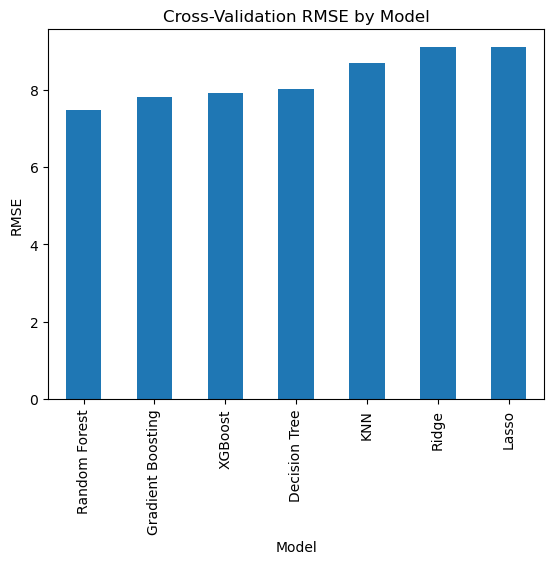

In [47]:
# Visualize CV RMSE comparison
cv_results.set_index('Model')['Best CV RMSE'].plot(kind='bar')
plt.title("Cross-Validation RMSE by Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

#### 9. Final Model Evaluation on Test Data

In [48]:
# Function to calculate final regression metrics
def evaluate_regression_model(model, X_test, y_test):
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Calculate MAE
    mae = mean_absolute_error(y_test, y_pred)
    
    # Calculate R-squared
    r2 = r2_score(y_test, y_pred)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

In [49]:
# Evaluate best version of each model on test set
results = pd.DataFrame({
    'Ridge': evaluate_regression_model(grid_ridge.best_estimator_, X_test, y_test),
    'Lasso': evaluate_regression_model(grid_lasso.best_estimator_, X_test, y_test),
    'Decision Tree': evaluate_regression_model(grid_dt.best_estimator_, X_test, y_test),
    'Random Forest': evaluate_regression_model(grid_rf.best_estimator_, X_test, y_test),
    'KNN': evaluate_regression_model(grid_knn.best_estimator_, X_test, y_test),
    'Gradient Boosting': evaluate_regression_model(grid_gb.best_estimator_, X_test, y_test),
    'XGBoost': evaluate_regression_model(grid_xgb.best_estimator_, X_test, y_test)
}).T

# Lower RMSE is better
results = results.sort_values(by='RMSE', ascending=True)

display(results)

,RMSE,MAE,R2
Random Forest,5.372024,3.658743,0.827976
XGBoost,5.729392,3.911898,0.804328
Gradient Boosting,5.961304,4.149407,0.788166
KNN,6.400792,4.588192,0.755781
Decision Tree,6.456652,4.727443,0.751500
Lasso,7.283654,5.304968,0.683764
Ridge,7.285876,5.295439,0.683571


#### 10. Select the Best Model

In [50]:
# Select best model based on lowest test RMSE
best_name = results.index[0]

best_model_dict = {
    'Ridge': grid_ridge.best_estimator_,
    'Lasso': grid_lasso.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'Gradient Boosting': grid_gb.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_
}

best_model = best_model_dict[best_name]

print("Best model:", best_name)

Best model: Random Forest


#### 11. Predicted vs Actual Values

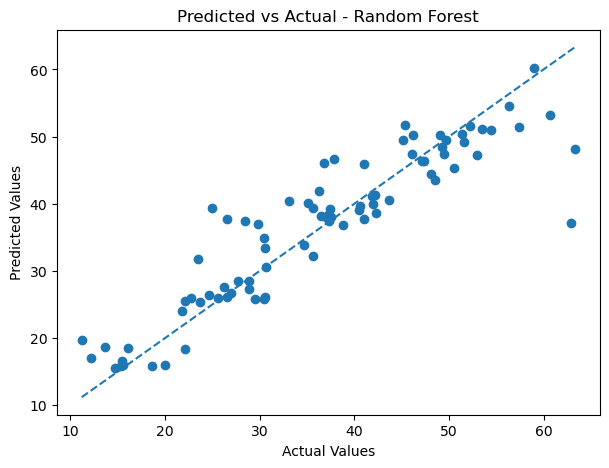

In [51]:
# Predict using the best model
y_pred_best = best_model.predict(X_test)

# Plot predicted vs actual values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Predicted vs Actual - {best_name}")

# Add ideal reference line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.show()

#### 12. Residuals vs Predictions

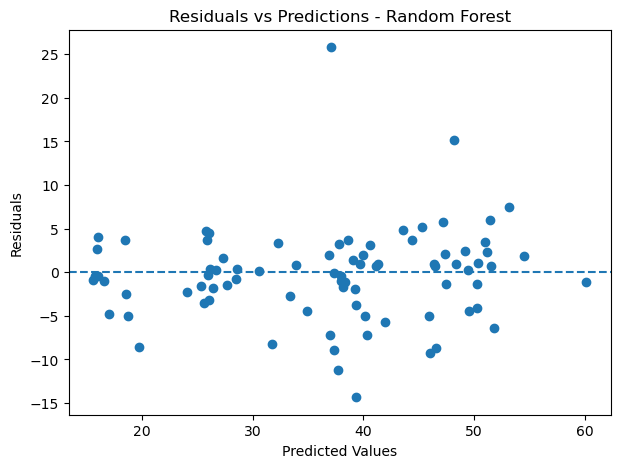

In [52]:
# Calculate residuals
residuals = y_test - y_pred_best

# Plot residuals vs predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_best, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residuals vs Predictions - {best_name}")
plt.show()

#### Conclusion

For the Real Estate Valuation dataset, several regression models were trained and tuned using GridSearchCV with 5-Fold Cross-Validation on the training set. The models evaluated included Ridge Regression, Lasso Regression, Decision Tree Regressor, Random Forest Regressor, KNN Regressor, Gradient Boosting Regressor, and XGBoost Regressor.

Model selection was primarily based on RMSE during cross-validation. After evaluating model performance on the test set using RMSE, MAE, and R², the **Random Forest Regressor** achieved the best predictive performance.

Best Hyperparameters:
- n_estimators = 200
- max_depth = 10
- min_samples_leaf = 3
- max_features = sqrt

Random Forest likely generalizes best because it averages predictions from multiple decision trees built on different subsets of the data and features. This reduces variance and overfitting while capturing nonlinear relationships between variables. The Predicted vs Actual plot and Residual plot also show stable performance on unseen data.
